# Continuous Systems

Let's think about simulating continuous systems. A continuous system is one that changes continuously over time, as opposed to discrete systems which change at specific intervals.

## Chemical Reaction Simulation

This simulation models a reversible chemical reaction where compounds A and B react to form C. The system is governed by the following differential equations:

$$\frac{d[A]}{dt} = -k_1[A][B] + k_2[C]$$

$$\frac{d[B]}{dt} = -k_1[A][B] + k_2[C]$$

$$\frac{d[C]}{dt} = 2(k_1[A][B] - k_2[C])$$

Then let's try the **Forward Euler Method**, which is a first-order numerical procedure for solving ODEs. It approximates the derivative by using a small time step ($\Delta t$):

$$[X]_{t+\Delta t} \approx [X]_t + \left( \frac{d[X]}{dt} \right) \Delta t$$


Where:
- $k_1 = 0.025$ is the forward reaction rate constant
- $k_2 = 0.01$ is the reverse reaction rate constant
- $[A]$, $[B]$, and $[C]$ represent the concentrations of compounds A, B, and C respectively

The simulation uses Euler's method with a time step of $\Delta t = 0.1$ to numerically integrate these equations over 15 time units, starting with initial concentrations $[A]_0 = 50.0$, $[B]_0 = 25.0$, and $[C]_0 = 0.0$.

Time	[A]	[B]	[C]
0.00	50.0000	25.0000	0.0000
0.10	46.8750	21.8750	6.2500
0.20	44.3178	19.3178	11.3645
0.30	42.1888	17.1888	15.6223
0.40	40.3915	15.3915	19.2170
0.50	38.8565	13.8565	22.2870
0.60	37.5328	12.5328	24.9345
0.70	36.3817	11.3817	27.2366
0.80	35.3737	10.3737	29.2525
0.90	34.4856	9.4856	31.0288
1.00	33.6988	8.6988	32.6023
1.10	32.9986	7.9986	34.0028
1.20	32.3727	7.3727	35.2545
1.30	31.8113	6.8113	36.3774
1.40	31.3060	6.3060	37.3880
1.50	30.8498	5.8498	38.3003
1.60	30.4370	5.4370	39.1261
1.70	30.0624	5.0624	39.8752
1.80	29.7218	4.7218	40.5564
1.90	29.4115	4.4115	41.1770
2.00	29.1283	4.1283	41.7434
2.10	28.8694	3.8694	42.2612
2.20	28.6324	3.6324	42.7352
2.30	28.4151	3.4151	43.1697
2.40	28.2157	3.2157	43.5686
2.50	28.0324	3.0324	43.9351
2.60	27.8639	2.8639	44.2723
2.70	27.7086	2.7086	44.5827
2.80	27.5656	2.5656	44.8688
2.90	27.4336	2.4336	45.1327
3.00	27.3119	2.3119	45.3763
3.10	27.1994	2.1994	45.6012
3.20	27.0954	2.0954	45.8091
3.30	26.9993	1.9993	46.0014
3.40	26.9104	1.9104	46.1

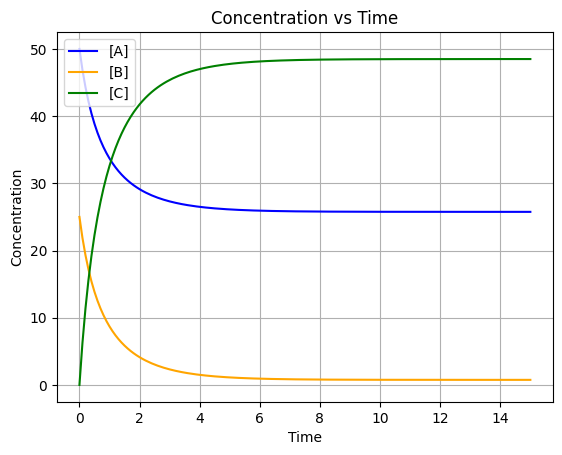

In [5]:
import matplotlib.pyplot as plt

class ChemicalReaction:
    def __init__(self, k1, k2, c1, c2, c3, time_diff=0.1):
        self.k1 = k1  # Rate constant for forward reaction
        self.k2 = k2  # Rate constant for reverse reaction
        self.c1 = c1  # Initial concentration of A
        self.c2 = c2  # Initial concentration of B
        self.c3 = c3  # Initial concentration of C
        self.time_diff = time_diff  # Time step for simulation

        self.time_points = [0]
        self.concentration_A = [c1]
        self.concentration_B = [c2]
        self.concentration_C = [c3]

    def simulate_reaction(self, total_time):
        steps = int(total_time / self.time_diff)
        for step in range(1, steps + 1):
            current_time = step * self.time_diff
            a = self.concentration_A[-1]
            b = self.concentration_B[-1]
            c = self.concentration_C[-1]

            # Calculate changes
            delta_a = (-self.k1 * a * b + self.k2 * c) * self.time_diff
            delta_b = (-self.k1 * a * b + self.k2 * c) * self.time_diff
            delta_c = 2 * (self.k1 * a * b - self.k2 * c) * self.time_diff

            # Update 
            new_a = a + delta_a
            new_b = b + delta_b
            new_c = c + delta_c

            # Append 
            self.time_points.append(current_time)
            self.concentration_A.append(new_a)
            self.concentration_B.append(new_b)
            self.concentration_C.append(new_c)

    def print_results(self):
        print("Time\t[A]\t[B]\t[C]")
        for t, a, b, c in zip(self.time_points, self.concentration_A, self.concentration_B, self.concentration_C):
            print(f"{t:.2f}\t{a:.4f}\t{b:.4f}\t{c:.4f}")

    def plot_concentrations(self):
        plt.plot(self.time_points, self.concentration_A, label='[A]', color='blue')
        plt.plot(self.time_points, self.concentration_B, label='[B]', color='orange')
        plt.plot(self.time_points, self.concentration_C, label='[C]', color='green')
        plt.title('Concentration vs Time')
        plt.xlabel('Time')
        plt.ylabel('Concentration')
        plt.legend()
        plt.grid()
        plt.show()

if __name__ == "__main__":
    reaction = ChemicalReaction(k1=0.025, k2=0.01, c1=50.0, c2=25.0, c3=0.0)
    reaction.simulate_reaction(total_time=15)
    reaction.print_results()
    reaction.plot_concentrations()